# propagateInside run: acoustic, elastic, and local free-surface patches

This notebook keeps the important modelling choices visible in cells: equation, material arrays, grid spacing, source, local boundary patch, propagation, snapshots, and videos.


In [ ]:
# Locate flexOPT securely without relying on @__DIR__ (unreliable in IJulia).
# If this notebook is outside the repository, set ENV["FLEXOPT_ROOT"] first.
import Pkg

function find_flexopt_root(start_dir=pwd())
    candidates = String[]
    if haskey(ENV, "FLEXOPT_ROOT")
        push!(candidates, abspath(expanduser(ENV["FLEXOPT_ROOT"])))
    end
    directory = abspath(start_dir)
    while true
        push!(candidates, directory)
        parent = dirname(directory)
        parent == directory && break
        directory = parent
    end
    for candidate in unique(candidates)
        project_file = joinpath(candidate, "Project.toml")
        source_dir = joinpath(candidate, "src")
        if isfile(project_file) && isfile(joinpath(source_dir, "commonBatchs.jl"))
            return candidate
        end
    end
    error("Cannot locate flexOPT. Start Jupyter inside the repository or set ENV[\"FLEXOPT_ROOT\"] to its absolute path.")
end

flexopt_root = find_flexopt_root()
Pkg.activate(flexopt_root)
@show VERSION Threads.nthreads() Base.active_project()
\ninclude(joinpath(flexopt_root, "src", "batchFiles", "batchGPU.jl"))
include(joinpath(flexopt_root, "src", "commonBatchs.jl"))
include(joinpath(flexopt_root, "src", "planet1D.jl"))
planet1D.configure_input!()
include(joinpath(flexopt_root, "src", "GeoPoints.jl"))
using .commonBatchs, .planet1D, .GeoPoints



include(joinpath(flexopt_root, "src", "flexOPT.jl"))
using .flexOPT

using LinearAlgebra, SparseArrays, Statistics
using JLD2
using CairoMakie
CairoMakie.activate!()\n

## User-visible run options


In [2]:
physics = :acoustic          # :acoustic or :elastic_moment
model_kind = :homogeneous    # :homogeneous or :marmousi
free_surface = :none         # :none, :neumann, or :dietrich
add_air_layer = false        # if true for elastic, top cells have rho = 0 and trigger free-surface patch

nx, nz = 121, 121
dx = 1.0e3                  # m; for Marmousi with step=1 this is native-ish debug spacing
cfl = 0.20
Nt = 180
store_every = 4
source_amplitude = 1.0
source_component = :M11      # acoustic ignores this; elastic moment: :M11 or :double_couple

pointsInSpace = 3
pointsInTime = 3
supplementaryOrder = 2
orderBspace = 1
orderBtime = 1
YorderBspace = -1
YorderBtime = -1
recipe_backend = CPU()
representation = "matrixfree"


"matrixfree"

## Model arrays

For `2DacousticTime`, `models = [v]`. For `2DsismoTimeIsoHetero`, `models = [rho, lambda_nd, mu_nd]` in the dimensionless form used for stable debug time marching: `rho = 1`, `lambda_nd=(lambda/rho)*(dt/dx)^2`, `mu_nd=(mu/rho)*(dt/dx)^2`. If `rho = 0`, that cell is treated as air/outside the solid for the local free-surface patch.


In [3]:
function center_crop(A, shape; step=1)
    B = A[1:step:end, 1:step:end]
    nxB, nzB = size(B)
    sx, sz = shape
    ix0 = max(1, cld(nxB - sx, 2) + 1)
    iz0 = max(1, cld(nzB - sz, 2) + 1)
    return B[ix0:min(ix0+sx-1, nxB), iz0:min(iz0+sz-1, nzB)]
end

function lame_from_rho_vp_vs(rho, vp, vs; rho_scale=1000.0, velocity_scale=1000.0)
    rho_mks = Float64.(rho) .* rho_scale
    vp_mks = Float64.(vp) .* velocity_scale
    vs_mks = Float64.(vs) .* velocity_scale
    mu = rho_mks .* vs_mks.^2
    lambda = rho_mks .* vp_mks.^2 .- 2 .* mu
    return rho_mks, lambda, mu, vp_mks, vs_mks
end

if model_kind == :marmousi
    marmousi = load(joinpath(@__DIR__, "tmp/seismicModelMarmousi.jld2"), "output")
    rho_raw = center_crop(marmousi.ρ, (nx, nz); step=1)
    vp_raw = center_crop(marmousi.Vpv, (nx, nz); step=1)
    vs_raw = center_crop(marmousi.Vsv, (nx, nz); step=1)
    rho_mks, lambda_mks, mu_mks, vp_mks, vs_mks = lame_from_rho_vp_vs(rho_raw, vp_raw, vs_raw)
else
    rho_mks = fill(2500.0, nx, nz)
    vp_mks = fill(3200.0, nx, nz)
    vs_mks = fill(1800.0, nx, nz)
    mu_mks = rho_mks .* vs_mks.^2
    lambda_mks = rho_mks .* vp_mks.^2 .- 2 .* mu_mks
end

if add_air_layer
    air_thickness = max(3, nz ÷ 12)
    rho_mks[:, 1:air_thickness] .= 0.0
    vp_mks[:, 1:air_thickness] .= 0.0
    vs_mks[:, 1:air_thickness] .= 0.0
    lambda_mks[:, 1:air_thickness] .= 0.0
    mu_mks[:, 1:air_thickness] .= 0.0
end

solid = rho_mks .> 0
v_for_dt = physics == :acoustic ? vp_mks[solid] : vp_mks[solid]
dt = cfl * dx / (sqrt(2) * maximum(v_for_dt))
Δ_mks = (dx, dx, dt)
Δ = (1.0, 1.0, 1.0)

if physics == :acoustic
    famousEquationType = "2DacousticTime"
    velocity_nd = vp_mks .* (dt / dx)
    velocity_nd[.!solid] .= 0.0
    models = [velocity_nd]
else
    famousEquationType = "2DsismoTimeIsoHetero"
    rho_nd = Float64.(solid)
    lambda_nd = zeros(Float64, nx, nz)
    mu_nd = zeros(Float64, nx, nz)
    lambda_nd[solid] .= (lambda_mks[solid] ./ rho_mks[solid]) .* (dt / dx)^2
    mu_nd[solid] .= (mu_mks[solid] ./ rho_mks[solid]) .* (dt / dx)^2
    models = [rho_nd, lambda_nd, mu_nd]
end

sourcePoint = CartesianIndex(cld(nx, 2), cld(nz, 2))
if !solid[sourcePoint]
    sourcePoint = findfirst(solid)
end

@show famousEquationType model_kind free_surface add_air_layer
@show size(models[1]) Δ_mks Δ sourcePoint Nt store_every
@show extrema(vp_mks[solid]) extrema(vs_mks[solid])
@show dt maximum(vp_mks[solid]) * (Nt * dt) / dx


famousEquationType = "2DacousticTime"
model_kind = :homogeneous
free_surface = :none
add_air_layer = false
size(models[1]) = (121, 121)
Δ_mks = (1000.0, 1000.0, 0.044194173824159216)
Δ = (1.0, 1.0, 1.0)
sourcePoint = CartesianIndex(61, 61)
Nt = 180
store_every = 4
extrema(vp_mks[solid]) = (3200.0, 3200.0)
extrema(vs_mks[solid]) = (1800.0, 1800.0)
dt = 0.044194173824159216
(maximum(vp_mks[solid]) * (Nt * dt)) / dx = 25.45584412271571


25.45584412271571

## Build OPT recipe and numerical operators


In [4]:
fieldItpl = (ptsSpace=1, ptsTime=1, offsetSpace=1, offsetTime=1, YorderBspace=YorderBspace, YorderBtime=YorderBtime)
materItpl = (ptsSpace=1, ptsTime=1, offsetSpace=1, offsetTime=1, YorderBspace=YorderBspace, YorderBtime=YorderBtime)
params_recipe = @strdict famousEquationType Δ orderBtime orderBspace pointsInSpace pointsInTime supplementaryOrder fieldItpl materItpl recipe_backend
optRec = makeOPTsemiSymbolic(params_recipe)
recette = optRec["recette"]
modelPoints = getModelPoints(models[1], pointsInTime, recette.numbersOfTheSystem.numbersOfTheSystemL.timeMarching)
modelFam = (models=models, modelPoints=modelPoints, Δ=Δ, modelName=String(famousEquationType))
params_num = @strdict optRec modelFam absorbingBoundaries=nothing maskedRegionInSpace=nothing representation
numOpt = numericalOperatorConstruction(params_num)
numOps = numOpt["numOperators"]
preparedLin0 = prepareLinearSystem(numOps)

@show preparedLin0.spaceShape preparedLin0.NField preparedLin0.NForceField preparedLin0.timePointsUsedForOneStep
@show size(preparedLin0.A_unknown) nnz(preparedLin0.A_unknown) nnz(preparedLin0.L_known) nnz(preparedLin0.R_force)


(vars, iVars) = (v(x, y), 1)
(vars, iVars) = (v(x, y), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Float64}, 3}, [2.0, 2.0, 2.0], Array{SVector{3, Int64}, 3})

390963

## Local free-surface operator patch

This cell modifies only the prepared local sparse operators. `:neumann` mirrors stencil entries that point into `rho == 0` back into the solid. `:dietrich` is the elastic experimental mirror: normal displacement is even and tangential displacement is odd relative to the local surface normal. Rows inside `rho == 0` are pinned to zero. Current validation status: acoustic `:neumann` passed a small smoke test. Elastic `:neumann`/`:dietrich` are deliberately left as experimental switches; on the tiny rho=0 smoke test they can still make the implicit matrix singular/unstable, so use them for inspection before trusting long runs.


In [5]:
function row_index(pointLinear, iField, Npoints)
    return pointLinear + (iField - 1) * Npoints
end

function col_index(pointLinear, iField, timeSlot, Npoints, NField)
    return pointLinear + (iField - 1) * Npoints + (timeSlot - 1) * Npoints * NField
end

function zero_sparse_row!(A::SparseMatrixCSC, row)
    for j in 1:size(A, 2)
        for ptr in A.colptr[j]:(A.colptr[j+1]-1)
            A.rowval[ptr] == row && (A.nzval[ptr] = 0.0)
        end
    end
    return A
end

function add_sparse_value!(A::SparseMatrixCSC, row, col, val)
    A[row, col] = A[row, col] + val
    return A
end

function patch_matrix_neighbour!(M, row, colPoint, field, timeSlot, mirrorPoint, mirrorField, mirrorSign, Npoints, NField)
    oldcol = col_index(colPoint, field, timeSlot, Npoints, NField)
    newcol = col_index(mirrorPoint, mirrorField, timeSlot, Npoints, NField)
    v = M[row, oldcol]
    v == 0 && return nothing
    M[row, oldcol] = 0.0
    add_sparse_value!(M, row, newcol, mirrorSign * v)
    return nothing
end

function free_surface_points(rho; atol=0.0)
    solid = rho .> atol
    pts = CartesianIndex{2}[]
    for I in CartesianIndices(rho)
        solid[I] || continue
        i, j = Tuple(I)
        touches_air = false
        for nb in (CartesianIndex(i-1,j), CartesianIndex(i+1,j), CartesianIndex(i,j-1), CartesianIndex(i,j+1))
            if checkbounds(Bool, rho, nb) && !solid[nb]
                touches_air = true
            end
        end
        touches_air && push!(pts, I)
    end
    return pts
end

function apply_free_surface_local(prepared, rho; mode=:none, atol=0.0)
    mode == :none && return prepared
    A = copy(prepared.A_unknown)
    L = copy(prepared.L_known)
    R = copy(prepared.R_force)
    Npoints = prepared.NpointsSpace
    NField = prepared.NField
    LI = LinearIndices(prepared.spaceShape)
    solid = rho .> atol

    # Air/void rows: enforce u_future = 0 and remove known/source couplings.
    for I in CartesianIndices(rho)
        solid[I] && continue
        p = LI[I]
        for f in 1:NField
            row = row_index(p, f, Npoints)
            zero_sparse_row!(A, row); zero_sparse_row!(L, row); zero_sparse_row!(R, row)
            A[row, row] = 1.0
        end
    end

    mode in (:neumann, :dietrich) || error("free_surface must be :none, :neumann, or :dietrich")
    for I in free_surface_points(rho; atol=atol)
        p = LI[I]
        i, j = Tuple(I)
        air_dirs = Tuple{Int,Int}[]
        for d in ((-1,0), (1,0), (0,-1), (0,1))
            nb = CartesianIndex(i + d[1], j + d[2])
            if checkbounds(Bool, rho, nb) && !solid[nb]
                push!(air_dirs, d)
            end
        end
        for d in air_dirs
            air = CartesianIndex(i + d[1], j + d[2])
            mirror = CartesianIndex(i - d[1], j - d[2])
            checkbounds(Bool, rho, mirror) && solid[mirror] || continue
            airp = LI[air]
            mirrorp = LI[mirror]
            normalField = abs(d[1]) == 1 ? 1 : min(2, NField)
            for eq in 1:NField, field in 1:NField
                row = row_index(p, eq, Npoints)
                mirrorField = field
                mirrorSign = 1.0
                if mode == :dietrich && NField >= 2
                    mirrorSign = field == normalField ? 1.0 : -1.0
                end
                for timeSlot in 1:2
                    patch_matrix_neighbour!(L, row, airp, field, timeSlot, mirrorp, mirrorField, mirrorSign, Npoints, NField)
                end
                patch_matrix_neighbour!(A, row, airp, field, 1, mirrorp, mirrorField, mirrorSign, Npoints, NField)
            end
        end
    end

    dropzeros!(A)
    dropzeros!(L)
    dropzeros!(R)

    # Safety net: if rho=0 removed all implicit future couplings for a row, pin that unknown to zero.
    for row in 1:size(A, 1)
        if abs(A[row, row]) <= 1e-14
            rowsum = sum(abs, @view A[row, :])
            if rowsum <= 1e-12
                zero_sparse_row!(A, row)
                zero_sparse_row!(L, row)
                zero_sparse_row!(R, row)
                A[row, row] = 1.0
            end
        end
    end
    dropzeros!(A)
    dropzeros!(L)
    dropzeros!(R)

    function b_fun!(b, knownInputs)
        nKnownField = length(prepared.known_lhs_template)
        knownFieldVec = @view knownInputs[1:nKnownField]
        knownForceVec = @view knownInputs[nKnownField+1:nKnownField+length(prepared.known_rhs_template)]
        b .= 0.0
        mul!(b, L, knownFieldVec, -one(eltype(b)), one(eltype(b)))
        mul!(b, R, knownForceVec, one(eltype(b)), one(eltype(b)))
        return b
    end
    function A_fun!(avec, knownInputs)
        avec .= vec(A)
        return avec
    end

    return merge(prepared, (
        A_unknown=A,
        L_known=L,
        R_force=R,
        A_template=copy(A),
        b_template=zero(prepared.b_template),
        var"A_fun!"=A_fun!,
        var"b_fun!"=b_fun!,
        free_surface_mode=mode,
    ))
end

rho_for_boundary = physics == :acoustic ? Float64.(models[1] .> 0) : models[1]
preparedLin = apply_free_surface_local(preparedLin0, rho_for_boundary; mode=free_surface, atol=0.0)
@show get(preparedLin, :free_surface_mode, :none) nnz(preparedLin.A_unknown) nnz(preparedLin.L_known)


get(preparedLin, :free_surface_mode, :none) = :none
nnz(preparedLin.A_unknown) = 130321
nnz(preparedLin.L_known) = 260642


260642

## Source and propagation


In [6]:
function ricker(t, t0, f0)
    a = pi * f0 * (t - t0)
    return (1 - 2a^2) * exp(-a^2)
end

function source_time_samples(Nt, dt, timePointsUsedForOneStep; t0=12dt, f0=0.04)
    ntime = Nt + timePointsUsedForOneStep - 1
    t = (0:ntime-1) .* dt
    return Float64.(ricker.(t, t0, f0))
end

function point_source_weights(prepared, point)
    w = zeros(Float64, prepared.NforcePoints)
    w[LinearIndices(prepared.spaceShape)[point]] = 1.0
    return w
end

function source_full(prepared, point, signal; amplitude=1.0, source_component=:M11)
    weights = point_source_weights(prepared, point)
    S = zeros(Float64, prepared.NforcePoints, prepared.NForceField, length(signal))
    if prepared.NForceField == 1
        for it in eachindex(signal)
            S[:, 1, it] .= amplitude .* weights .* signal[it]
        end
    elseif prepared.NForceField == 4 && source_component == :double_couple
        moment = (1.0, 1.0, 1.0, -1.0) # M11, M12, M21, M22
        for it in eachindex(signal), k in 1:4
            S[:, k, it] .= amplitude .* moment[k] .* weights .* signal[it]
        end
    else
        field = source_component == :M22 ? 4 : source_component == :M12 ? 2 : source_component == :M21 ? 3 : 1
        for it in eachindex(signal)
            S[:, field, it] .= amplitude .* weights .* signal[it]
        end
    end
    return S
end

function propagate(prepared, Nt; sourceFull=nothing, store_every=1, blowup_limit=Inf, singular_diagonal_shift=1e-10)
    Npoints = prepared.NpointsSpace
    NField = prepared.NField
    NForceField = prepared.NForceField
    Nknown = prepared.timePointsUsedForOneStep - 1
    Nknown == 2 || error("this notebook assumes 3 time levels")
    if sourceFull === nothing
        sourceFull = zeros(Float64, prepared.NforcePoints, NForceField, Nt + prepared.timePointsUsedForOneStep - 1)
    end

    knownField = zeros(Float64, Npoints, NField, 2)
    knownForce = zero(prepared.known_rhs_template)
    unknown = zeros(Float64, Npoints, NField)
    A = sparse(prepared.A_template)
    factor = try
        lu(A)
    catch err
        if err isa SingularException && singular_diagonal_shift > 0
            @warn "A_unknown is singular; retrying with a small diagonal shift" singular_diagonal_shift
            lu(A + singular_diagonal_shift * I)
        else
            rethrow(err)
        end
    end
    b = copy(prepared.b_template)
    frames = Array{Float64}[]
    push!(frames, reshape(copy(unknown), prepared.spaceShape..., NField))
    for it in 1:Nt
        knownForce .= sourceFull[:, :, it:it+prepared.timePointsUsedForOneStep-1]
        prepared.b_fun!(b, vcat(vec(knownField), vec(knownForce)))
        u = factor \ b
        unknown .= reshape(real.(u), Npoints, NField)
        umax = maximum(abs, unknown)
        if !isfinite(umax) || umax > blowup_limit
            @warn "stopping propagation" it umax blowup_limit
            break
        end
        if it % store_every == 0 || it == Nt
            push!(frames, reshape(copy(unknown), prepared.spaceShape..., NField))
        end
        knownField[:, :, 1] .= knownField[:, :, 2]
        knownField[:, :, 2] .= unknown
    end
    return frames
end

f0 = physics == :acoustic ? median(vp_mks[solid]) / (10dx) : median(vs_mks[solid]) / (10dx)
t0 = min(12dt, 0.25Nt*dt)
timeSignal = source_time_samples(Nt, dt, preparedLin.timePointsUsedForOneStep; t0=t0, f0=f0)
sourceFull = source_full(preparedLin, sourcePoint, timeSignal; amplitude=source_amplitude, source_component=source_component)
frames = propagate(preparedLin, Nt; sourceFull=sourceFull, store_every=store_every, blowup_limit=1e8)

field1 = [frame[:, :, 1] for frame in frames]
field2 = preparedLin.NField >= 2 ? [frame[:, :, 2] for frame in frames] : nothing
@show length(frames) maximum(abs, field1[end])
field2 !== nothing && @show maximum(abs, field2[end])


length(frames) = 46
maximum(abs, field1[end]) = 3.4180481954983244


false

## Snapshots and videos


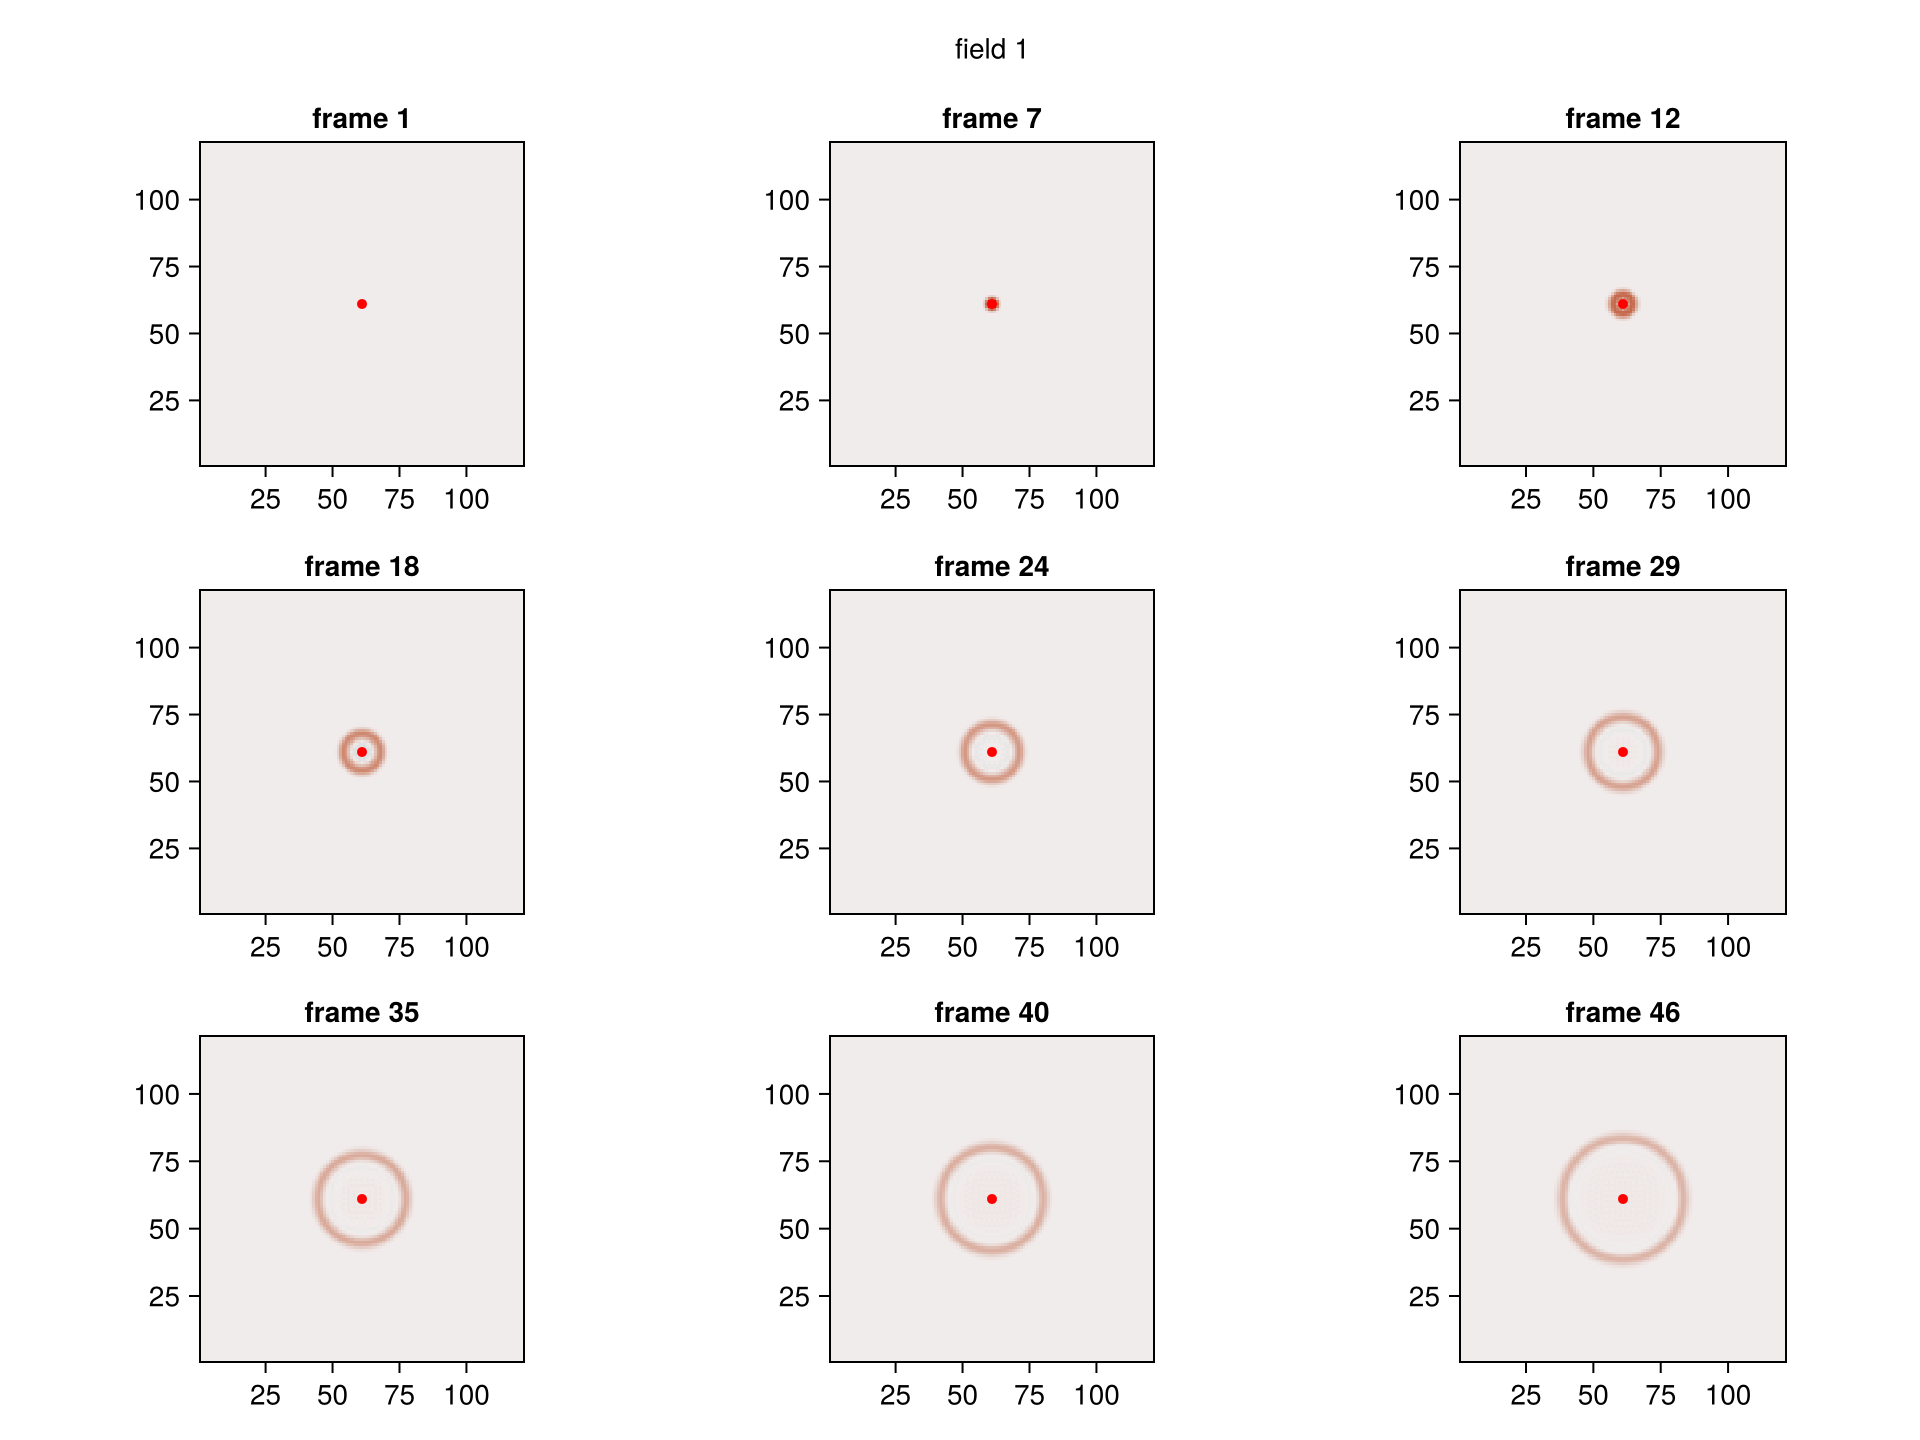

In [7]:
function snapshot_indices(frames; maxframes=9)
    return unique(round.(Int, range(1, length(frames), length=min(maxframes, length(frames)))))
end

function plot_snapshots(frames; title="wavefield", sourcePoint=nothing, clim=nothing)
    ids = snapshot_indices(frames)
    panels = [frames[i] for i in ids]
    vmax = clim === nothing ? maximum(maximum(abs, p) for p in panels) : clim
    vmax = vmax == 0 ? 1.0 : vmax
    fig = Figure(size=(960, 720))
    for (k, id) in enumerate(ids)
        ax = Axis(fig[cld(k,3), k - (cld(k,3)-1)*3], aspect=DataAspect(), title="frame $id")
        heatmap!(ax, panels[k]; colormap=:balance, colorrange=(-vmax, vmax))
        if sourcePoint !== nothing
            xy = Tuple(sourcePoint)
            scatter!(ax, [xy[1]], [xy[2]], color=:red, markersize=7)
        end
    end
    Label(fig[0, :], title)
    return fig
end

display(plot_snapshots(field1; title="field 1", sourcePoint=sourcePoint))
if field2 !== nothing
    display(plot_snapshots(field2; title="field 2", sourcePoint=sourcePoint))
end


In [8]:
function record_component_video(frames; filename, background=nothing, sourcePoint=nothing, title="wave", clim=nothing, framerate=20)
    vmax = clim === nothing ? maximum(maximum(abs, f) for f in frames) : clim
    vmax = vmax == 0 ? 1.0 : vmax
    fig = Figure(size=(760, 640))
    ax = Axis(fig[1,1], aspect=DataAspect(), title=title)
    if background !== nothing
        heatmap!(ax, Float64.(background); colormap=:grays, colorrange=extrema(Float64.(background)))
    end
    obs = Observable(Float64.(frames[1]))
    heatmap!(ax, obs; colormap=:balance, colorrange=(-vmax, vmax))
    if sourcePoint !== nothing
        xy = Tuple(sourcePoint)
        scatter!(ax, [xy[1]], [xy[2]], color=:red, markersize=7)
    end
    record(fig, filename, eachindex(frames); framerate=framerate) do i
        obs[] = Float64.(frames[i])
        ax.title = "$title frame $i / $(length(frames))"
    end
    return filename
end

video_dir = joinpath(@__DIR__, "tmp", "videos")
mkpath(video_dir)
background = physics == :acoustic ? vp_mks : vp_mks
video1 = joinpath(video_dir, "propagateInside_$(famousEquationType)_field1_$(free_surface).mp4")
record_component_video(field1; filename=video1, background=background, sourcePoint=sourcePoint, title="$(famousEquationType) field1 $(free_surface)")
if field2 !== nothing
    video2 = joinpath(video_dir, "propagateInside_$(famousEquationType)_field2_$(free_surface).mp4")
    record_component_video(field2; filename=video2, background=background, sourcePoint=sourcePoint, title="$(famousEquationType) field2 $(free_surface)")
    @show video1 video2
else
    @show video1
end


ErrorException: Can't interpolate in a range where cmin == cmax. This can happen, for example, if a colorrange is set automatically but there's only one unique value present.